In [1]:
from kipy import KiCad
from kipy.geometry import Vector2, Angle
from kipy.board_types import (
    BoardLayer,
    BoardSegment,
    BoardRectangle,
    BoardCircle,
    BoardArc,
    BoardPolygon,
    to_concrete_board_shape,
)
from dataclasses import dataclass, field
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

if __name__ == "__main__":
    try:
        kicad = KiCad()
        print(f"Connected to KiCad {kicad.get_version()}")
    except BaseException as e:
        print(f"Not connected to KiCad: {e}")

Connected to KiCad 10.0.1 (10.0.1)


In [2]:
@dataclass
class Pin:
    local_pos: np.ndarray
    net: str


@dataclass
class Component:
    id: str
    pos: np.ndarray
    theta: float = 0.0
    half_size: np.ndarray = field(default_factory=lambda: np.array([2.5, 2.5]))
    pins: list = field(default_factory=list)
    fixed: bool = False

def rot(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def pin_world(comp, pin):
    return comp.pos + rot(comp.theta) @ pin.local_pos


def rebuild_nets(components):
    nets = {}
    for cid, comp in components.items():
        for pi, pin in enumerate(comp.pins):
            nets.setdefault(pin.net, []).append((cid, pi))
    return nets


def hpwl(components):
    total = 0.0
    for members in rebuild_nets(components).values():
        if len(members) < 2:
            continue
        pts = np.array(
            [pin_world(components[c], components[c].pins[p]) for c, p in members]
        )
        total += np.ptp(pts[:, 0]) + np.ptp(pts[:, 1])
    return total

def draw(components, board, title="", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.add_patch(patches.Polygon(board, facecolor="#f6f6e8", edgecolor="#444"))
    for net, members in rebuild_nets(components).items():
        if len(members) < 2:
            continue
        pts = [pin_world(components[c], components[c].pins[p]) for c, p in members]
        ctr = np.mean(pts, axis=0)
        for p in pts:
            ax.plot(
                [p[0], ctr[0]], [p[1], ctr[1]], "-", color="#6b6", alpha=0.6, lw=0.8
            )
    for cid, c in components.items():
        box = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]]) * c.half_size
        corners = (rot(c.theta) @ box.T).T + c.pos
        color = "#fcc" if c.fixed else "#cce"
        ax.add_patch(patches.Polygon(corners, facecolor=color, edgecolor="#225"))
        ax.text(*c.pos, cid, ha="center", va="center", fontsize=6.5)
        for p in c.pins:
            ax.plot(*pin_world(c, p), "o", color="#225", markersize=2)
    ax.autoscale_view()
    ax.grid(alpha=0.2)
    return ax

In [3]:
board = kicad.get_board()
footprints = board.get_footprints()

for f in footprints:
    print(f"{f.reference_field.text.value}")

R1
R2


In [4]:
# Get board

def n2m(v):
    NM = 1e6  # nanometres per millimetre
    return np.array([v.x, v.y]) / NM

def rect(lo, hi):
    lo, hi = np.asarray(lo, float), np.asarray(hi, float)
    return np.array([lo, [hi[0], lo[1]], hi, [lo[0], hi[1]]])

def get_edge_cuts(board):
    shape = next((s for s in board.get_shapes() if s.layer == BoardLayer.BL_Edge_Cuts), None)
    if not shape:
        return None
    box = board.get_item_bounding_box(shape)
    if not box: raise Error
    return rect(n2m(box.pos), n2m(box.pos) + n2m(box.size))

get_edge_cuts(board)

array([[ 38.925, 113.775],
       [116.075, 113.775],
       [116.075, 147.175],
       [ 38.925, 147.175]])

In [8]:
def calc_half_size(board, fp):
    CRTYD = (BoardLayer.BL_F_CrtYd, BoardLayer.BL_B_CrtYd)
    box = None
    for s in fp.definition.shapes:
        if s.layer in CRTYD:
            b = to_concrete_board_shape(s).bounding_box()
            box = b if box is None else (box.merge(b) or box)
        if box is None:
            box = board.get_item_bounding_box(fp)
        return n2m(box.size) / 2 if box is not None else np.array([0.5, 0.5])
    
def get_components(board):
    components = {}
    for fp in board.get_footprints():
        ref = fp.reference_field.text.value
        pos = n2m(fp.position)
        theta = fp.orientation.to_radians()
        Rinv = rot(-theta)
        pins = [Pin(local_pos=Rinv @ (n2m(p.position) - pos), net=p.net.name)
                for p in fp.definition.pads]
        components[ref] = Component(
            id=ref,
            pos=pos,
            theta=theta,
            half_size=calc_half_size(board, fp),
            pins=pins,
            fixed=fp.locked,
        )
    return components
get_components(board)

{'R1': Component(id='R1', pos=array([ 60.85, 130.55]), theta=0.0, half_size=array([1.705, 0.975]), pins=[Pin(local_pos=array([-0.9125,  0.    ]), net='unconnected-(R1-Pad1)'), Pin(local_pos=array([0.9125, 0.    ]), net='unconnected-(R1-Pad2)')], fixed=False),
 'R2': Component(id='R2', pos=array([ 72.25, 130.85]), theta=0.0, half_size=array([1.705, 0.975]), pins=[Pin(local_pos=array([-0.9125,  0.    ]), net='unconnected-(R2-Pad1)'), Pin(local_pos=array([0.9125, 0.    ]), net='unconnected-(R2-Pad2)')], fixed=False)}

{'R1': Component(id='R1', pos=array([ 60.85, 130.55]), theta=0.0, half_size=array([1.705, 0.975]), pins=[Pin(local_pos=array([-0.9125,  0.    ]), net='Net-(R1-Pad1)'), Pin(local_pos=array([0.9125, 0.    ]), net='Net-(R1-Pad2)')], fixed=False),
 'R2': Component(id='R2', pos=array([ 72.25, 130.85]), theta=0.0, half_size=array([1.705, 0.975]), pins=[Pin(local_pos=array([-0.9125,  0.    ]), net='Net-(R1-Pad2)'), Pin(local_pos=array([0.9125, 0.    ]), net='Net-(R1-Pad1)')], fixed=False)}

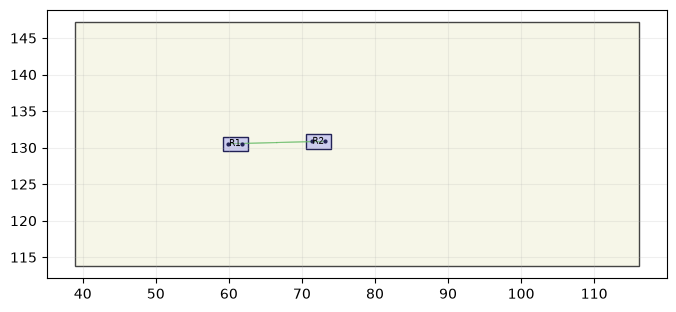

In [10]:
draw(get_components(board), get_edge_cuts(board))
get_components(board)
